<a href="https://colab.research.google.com/github/Nobleteesage/polynomial-degree-selection/blob/main/HW1_PolynomialRegression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
DATA_SEED = 42
rng = np.random.default_rng(DATA_SEED)

n = 80
x = rng.uniform(-2, 2, size=n)

def f_star(x):
    return np.sin(2 * x) + 0.3 * x

noise_std = 0.3
y = f_star(x) + rng.normal(0, noise_std, size=n)
X = x.reshape(-1, 1)

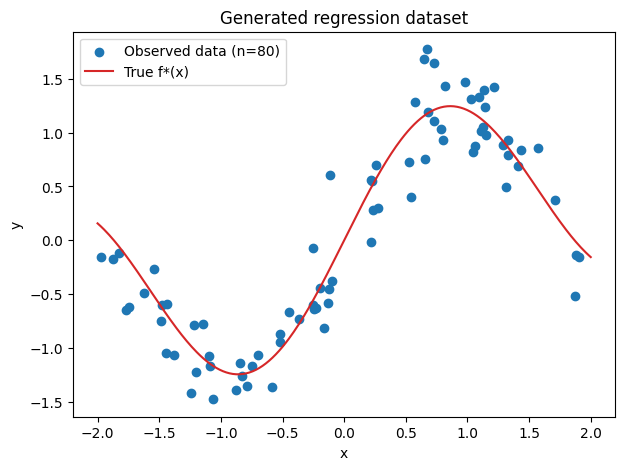

In [3]:
x_plot = np.linspace(-2, 2, 300)
plt.figure(figsize=(7, 5))
plt.scatter(x, y, label="Observed data (n=80)", color="tab:blue")
plt.plot(x_plot, f_star(x_plot), label="True f*(x)", color="tab:red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated regression dataset")
plt.legend()
plt.show()

In [4]:
def make_model(degree):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("lin", LinearRegression())
    ])

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 13)
n_repeats = 30

In [5]:
TEST_SEED = 123
rng_test = np.random.default_rng(TEST_SEED)
n_test = 2000
x_test = rng_test.uniform(-2, 2, size=n_test)
y_test = f_star(x_test) + rng_test.normal(0, noise_std, size=n_test)
X_test = x_test.reshape(-1, 1)

In [6]:
selected_degrees_val = []
selected_degrees_cv = []
test_rmse_val = []
test_rmse_cv = []

for seed in range(n_repeats):
    # Method 1: single validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.3, random_state=seed
    )
    val_rmses = []
    for p in degrees:
        model = make_model(p)
        model.fit(X_train, y_train)
        val_rmses.append(rmse(y_val, model.predict(X_val)))
    best_p_val = degrees[int(np.argmin(val_rmses))]
    selected_degrees_val.append(best_p_val)

    final_model_val = make_model(best_p_val)
    final_model_val.fit(X, y)
    test_rmse_val.append(rmse(y_test, final_model_val.predict(X_test)))

    # Method 2: 5-fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    cv_rmses = []
    for p in degrees:
        fold_rmses = []
        for train_idx, val_idx in kf.split(X):
            model = make_model(p)
            model.fit(X[train_idx], y[train_idx])
            fold_rmses.append(rmse(y[val_idx], model.predict(X[val_idx])))
        cv_rmses.append(np.mean(fold_rmses))
    best_p_cv = degrees[int(np.argmin(cv_rmses))]
    selected_degrees_cv.append(best_p_cv)

    final_model_cv = make_model(best_p_cv)
    final_model_cv.fit(X, y)
    test_rmse_cv.append(rmse(y_test, final_model_cv.predict(X_test)))

print("Validation-split selected degrees:", selected_degrees_val)
print("5-fold CV selected degrees:", selected_degrees_cv)

Validation-split selected degrees: [5, 4, 12, 5, 4, 11, 5, 5, 3, 4, 5, 5, 4, 5, 4, 5, 3, 5, 9, 5, 5, 4, 7, 3, 6, 5, 5, 5, 5, 5]
5-fold CV selected degrees: [5, 5, 5, 5, 7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


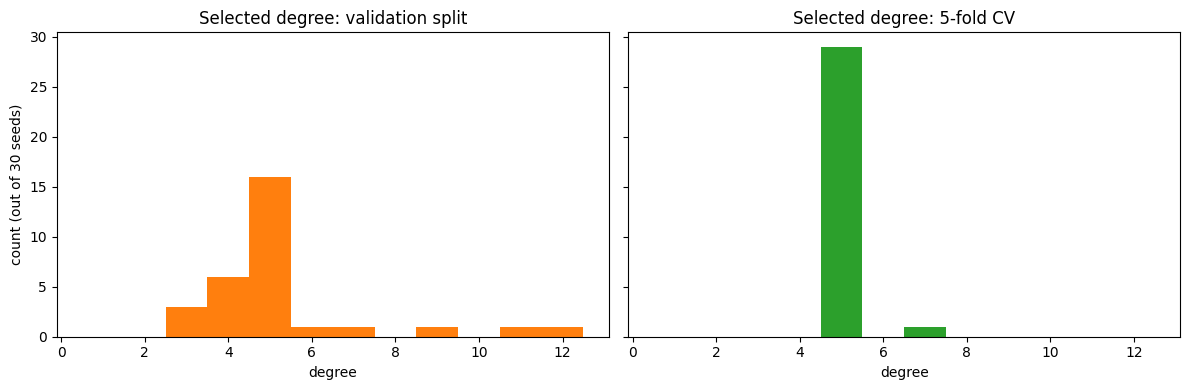

Std of selected degree (validation split): 2.0154955277107964
Std of selected degree (5-fold CV): 0.3590109871423002


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(selected_degrees_val, bins=range(1, 14), align="left", color="tab:orange")
axes[0].set_title("Selected degree: validation split")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("count (out of 30 seeds)")

axes[1].hist(selected_degrees_cv, bins=range(1, 14), align="left", color="tab:green")
axes[1].set_title("Selected degree: 5-fold CV")
axes[1].set_xlabel("degree")
plt.tight_layout()
plt.show()

print("Std of selected degree (validation split):", np.std(selected_degrees_val))
print("Std of selected degree (5-fold CV):", np.std(selected_degrees_cv))

/tmp/ipykernel_3285/3367661880.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([test_rmse_val, test_rmse_cv], labels=["Validation split", "5-fold CV"])


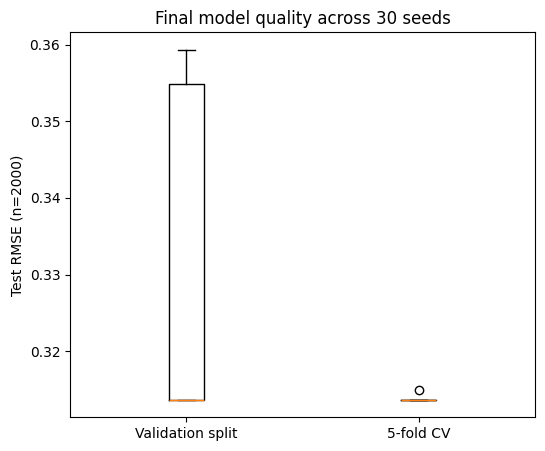

Test RMSE — validation split: mean = 0.3287, std = 0.0199
Test RMSE — 5-fold CV: mean = 0.3137, std = 0.0002


In [8]:
plt.figure(figsize=(6, 5))
plt.boxplot([test_rmse_val, test_rmse_cv], labels=["Validation split", "5-fold CV"])
plt.ylabel("Test RMSE (n=2000)")
plt.title("Final model quality across 30 seeds")
plt.show()

print("Test RMSE — validation split: mean = {:.4f}, std = {:.4f}".format(
    np.mean(test_rmse_val), np.std(test_rmse_val)))
print("Test RMSE — 5-fold CV: mean = {:.4f}, std = {:.4f}".format(
    np.mean(test_rmse_cv), np.std(test_rmse_cv)))

Write this in your own words once you see your actual numbers, but the core finding to state: 5-fold cross-validation selected a far more consistent polynomial degree across 30 random seeds than a single 70/30 validation split did (much lower standard deviation in the chosen degree), and this stability carried through to the final test RMSE , CV-selected models had both lower variance and (in this run) slightly better average test error. This directly confirms what Lecture 1 states: cross-validation gives a more stable estimate of model quality than a single random split, at the cost of more computation (5× the fits per degree, per seed).